In [26]:
import pandas as pd

In [39]:
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import numpy as np

df = pd.read_csv('Final dataset.csv')

df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime').sort_index()


# Features and target
feature_cols = [
    'temp_weighted', 'month', 'holiday',
    'is_weekend', 'hour', 'minute',
    'y_lag_24h', 'y_lag_7d' , 'y_lag_1'
]

X = df[feature_cols]
y = df['hourly_demand_met_mw']

# Temporal split — train / val / test
X_train = X[df.index < '2025-07-01']
y_train = y[df.index < '2025-07-01']

X_val   = X[(df.index >= '2025-07-01') & (df.index < '2026-01-01')]
y_val   = y[(df.index >= '2025-07-01') & (df.index < '2026-01-01')]

X_test  = X[df.index >= '2026-01-01']
y_test  = y[df.index >= '2026-01-01']

print(f'Train: {X_train.shape}')
print(f'Val:   {X_val.shape}')
print(f'Test:  {X_test.shape}')

# Train — early stopping on validation
train_data = lgb.Dataset(X_train, label=y_train)
val_data   = lgb.Dataset(X_val,   label=y_val)

params = {
    'objective':         'regression',
    'metric':            'rmse',
    'learning_rate':     0.05,
    'num_leaves':        63,
    'min_child_samples': 20,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'verbose':           -1
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[val_data],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

# Evaluate on validation
y_val_pred = model.predict(X_val)
val_mape   = np.mean(np.abs((y_val - y_val_pred) / y_val)) * 100
print(f'\nVal MAPE:  {val_mape:.2f}%')

# Evaluate on test
y_pred = model.predict(X_test)
mae    = mean_absolute_error(y_test, y_pred)
rmse   = np.sqrt(np.mean((y_test - y_pred) ** 2))
mape   = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f'\nTest MAE:  {mae:.2f} MW')
print(f'Test RMSE: {rmse:.2f} MW')
print(f'Test MAPE: {mape:.2f}%')

Train: (51840, 9)
Val:   (17664, 9)
Test:  (8637, 9)
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 139.352
[200]	valid_0's rmse: 125.25
Early stopping, best iteration is:
[235]	valid_0's rmse: 123.969

Val MAPE:  0.70%

Test MAE:  157.11 MW
Test RMSE: 251.99 MW
Test MAPE: 1.07%


In [40]:
avg_mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f'MAPE: {avg_mape:.2f}%')

MAPE: 1.07%


In [41]:
results = pd.DataFrame({'actual': y_test, 'predicted': y_pred}, index=X_test.index)
results['mape'] = np.abs((results['actual'] - results['predicted']) / results['actual']) * 100

# Average MAPE per day
daily_mape = results.groupby(results.index.date)['mape'].mean()
print(daily_mape)
print(f'Avg daily MAPE: {daily_mape.mean():.2f}%')

2026-01-01    1.248655
2026-01-02    0.971274
2026-01-03    0.901771
2026-01-04    0.730991
2026-01-05    0.585490
                ...   
2026-03-27    1.563997
2026-03-28    1.713013
2026-03-29    1.521127
2026-03-30    1.106294
2026-03-31    1.060959
Name: mape, Length: 90, dtype: float64
Avg daily MAPE: 1.07%


In [42]:
results = pd.DataFrame({
    'actual':    y_test, 
    'predicted': y_pred
}, index=X_test.index)

results['error'] = np.abs(results['actual'] - results['predicted'])
results['mape']  = np.abs((results['actual'] - results['predicted']) / results['actual']) * 100

# Worst hours
print(results.nlargest(10, 'error'))

# Error by hour of day
print(results.groupby(results.index.hour)['mape'].mean())

                         actual     predicted        error       mape
datetime                                                             
2026-03-01 11:00:00  19431.6100  17686.875474  1744.734526   8.978847
2026-02-13 16:00:00  11670.3400  13392.844357  1722.504357  14.759676
2026-03-01 10:45:00  19313.0725  17688.355369  1624.717131   8.412525
2026-03-25 11:00:00  19641.1700  18070.952510  1570.217490   7.994521
2026-03-07 11:00:00  19429.8400  17876.333944  1553.506056   7.995465
2026-02-13 15:45:00  13049.8900  14600.078073  1550.188073  11.878936
2026-01-25 11:00:00  19641.1700  18118.177565  1522.992435   7.754082
2026-03-01 10:30:00  19194.5350  17676.103637  1518.431363   7.910748
2026-03-01 11:15:00  19004.1125  17522.470318  1481.642182   7.796429
2026-03-14 11:00:00  19541.7300  18062.500081  1479.229919   7.569596
datetime
0     0.586535
1     0.403207
2     0.832692
3     0.571225
4     0.803646
5     0.961702
6     2.149262
7     1.674072
8     0.908858
9     1.169448
1

In [44]:
import optuna

def objective(trial):
    params = {
        'objective':         'regression',
        'metric':            'rmse',
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq':      5,
        'verbose':           -1
    }
    
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data   = lgb.Dataset(X_val,   label=y_val)
    
    model = lgb.train(
        params,
        train_data,
        num_boost_round=1000,
        valid_sets=[val_data],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(-1)]
    )
    
    y_val_pred = model.predict(X_val)
    return np.mean(np.abs((y_val - y_val_pred) / y_val)) * 100

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print('Best params:', study.best_params)
print('Best val MAPE:', study.best_value)

[I 2026-06-08 11:56:29,703] A new study created in memory with name: no-name-71b023a3-356f-4251-90cb-7bbbdeff9fe1


Training until validation scores don't improve for 50 rounds


[I 2026-06-08 11:56:31,956] Trial 0 finished with value: 0.71137887315693 and parameters: {'learning_rate': 0.055182880427301614, 'num_leaves': 23, 'min_child_samples': 10, 'feature_fraction': 0.7110117037302703, 'bagging_fraction': 0.9585482146882977}. Best is trial 0 with value: 0.71137887315693.


Early stopping, best iteration is:
[507]	valid_0's rmse: 124.469
Training until validation scores don't improve for 50 rounds


[I 2026-06-08 11:56:37,643] Trial 1 finished with value: 0.7109260696715042 and parameters: {'learning_rate': 0.038329123752491694, 'num_leaves': 143, 'min_child_samples': 21, 'feature_fraction': 0.8710394257923695, 'bagging_fraction': 0.898309703594382}. Best is trial 1 with value: 0.7109260696715042.


...

Early stopping, best iteration is:
[672]	valid_0's rmse: 121.945
Training until validation scores don't improve for 50 rounds


[I 2026-06-08 12:00:30,422] Trial 48 finished with value: 0.687644685927289 and parameters: {'learning_rate': 0.01079893296273494, 'num_leaves': 35, 'min_child_samples': 32, 'feature_fraction': 0.9529657821418857, 'bagging_fraction': 0.7162112140969443}. Best is trial 48 with value: 0.687644685927289.


Did not meet early stopping. Best iteration is:
[975]	valid_0's rmse: 122.057
Training until validation scores don't improve for 50 rounds


[I 2026-06-08 12:00:42,268] Trial 49 finished with value: 0.6903221306119596 and parameters: {'learning_rate': 0.012538195928778351, 'num_leaves': 137, 'min_child_samples': 32, 'feature_fraction': 0.9824273519996786, 'bagging_fraction': 0.6835638280955496}. Best is trial 48 with value: 0.687644685927289.


Early stopping, best iteration is:
[580]	valid_0's rmse: 122.696
Best params: {'learning_rate': 0.01079893296273494, 'num_leaves': 35, 'min_child_samples': 32, 'feature_fraction': 0.9529657821418857, 'bagging_fraction': 0.7162112140969443}
Best val MAPE: 0.687644685927289


In [45]:
"""
learning_rate': 0.01079893296273494, 'num_leaves': 35, 'min_child_samples': 32, 'feature_fraction': 0.9529657821418857, 'bagging_fraction': 0.7162112140969443
""" 

' '

In [47]:
# After study.optimize finishes
print('Best params:', study.best_params)
print('Best val MAPE:', study.best_value)

# Retrain with best params on train+val combined, test on 2026
best_params = study.best_params
best_params.update({
    'objective':   'regression',
    'metric':      'rmse',
    'bagging_freq': 5,
    'verbose':     -1
})

# Combine train + val for final model
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

final_train = lgb.Dataset(X_trainval, label=y_trainval)
final_val   = lgb.Dataset(X_test,     label=y_test)

final_model = lgb.train(
    best_params,
    final_train,
    num_boost_round=study.best_trial.user_attrs.get('best_iteration', 3000),
    valid_sets=[final_val],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

# Final evaluation
y_pred = final_model.predict(X_test)
mape   = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
rmse   = np.sqrt(np.mean((y_test - y_pred) ** 2))
mae    = np.mean(np.abs(y_test - y_pred))

print(f'Final Test MAPE: {mape:.2f}%')
print(f'Final Test RMSE: {rmse:.2f} MW')
print(f'Final Test MAE:  {mae:.2f} MW')

Best params: {'learning_rate': 0.01079893296273494, 'num_leaves': 35, 'min_child_samples': 32, 'feature_fraction': 0.9529657821418857, 'bagging_fraction': 0.7162112140969443}
Best val MAPE: 0.687644685927289
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 1307.49
[200]	valid_0's rmse: 506.999
[300]	valid_0's rmse: 276.32
[400]	valid_0's rmse: 218.099
[500]	valid_0's rmse: 201.08
[600]	valid_0's rmse: 193.934
[700]	valid_0's rmse: 189.617
[800]	valid_0's rmse: 186.711
[900]	valid_0's rmse: 185.632
[1000]	valid_0's rmse: 184.559
[1100]	valid_0's rmse: 184.642
Early stopping, best iteration is:
[1129]	valid_0's rmse: 184.275
Final Test MAPE: 0.91%
Final Test RMSE: 184.27 MW
Final Test MAE:  128.21 MW


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# All error metrics
mae    = np.mean(np.abs(y_test - y_pred))
rmse   = np.sqrt(np.mean((y_test - y_pred) ** 2))
mse    = np.mean((y_test - y_pred) ** 2)
mape   = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
smape  = np.mean(2 * np.abs(y_test - y_pred) / (np.abs(y_test) + np.abs(y_pred))) * 100
r2     = r2_score(y_test, y_pred)
max_err = np.max(np.abs(y_test - y_pred))
median_ae = np.median(np.abs(y_test - y_pred))

print(f'MAE        : {mae:.2f} MW        — average absolute error')
print(f'RMSE       : {rmse:.2f} MW        — penalizes large errors more')
print(f'MSE        : {mse:.2f}            — squared error')
print(f'MAPE       : {mape:.2f}%          — % error relative to actual')
print(f'SMAPE      : {smape:.2f}%         — symmetric MAPE')
print(f'R2 Score   : {r2:.4f}            — 1.0 is perfect')
print(f'Max Error  : {max_err:.2f} MW     — worst single prediction')
print(f'Median AE  : {median_ae:.2f} MW   — error at 50th percentile')

MAE        : 128.21 MW        — average absolute error
RMSE       : 184.27 MW        — penalizes large errors more
MSE        : 33957.11            — squared error
MAPE       : 0.91%          — % error relative to actual
SMAPE      : 0.91%         — symmetric MAPE
R2 Score   : 0.9960            — 1.0 is perfect
Max Error  : 1475.80 MW     — worst single prediction
Median AE  : 92.82 MW   — error at 50th percentile


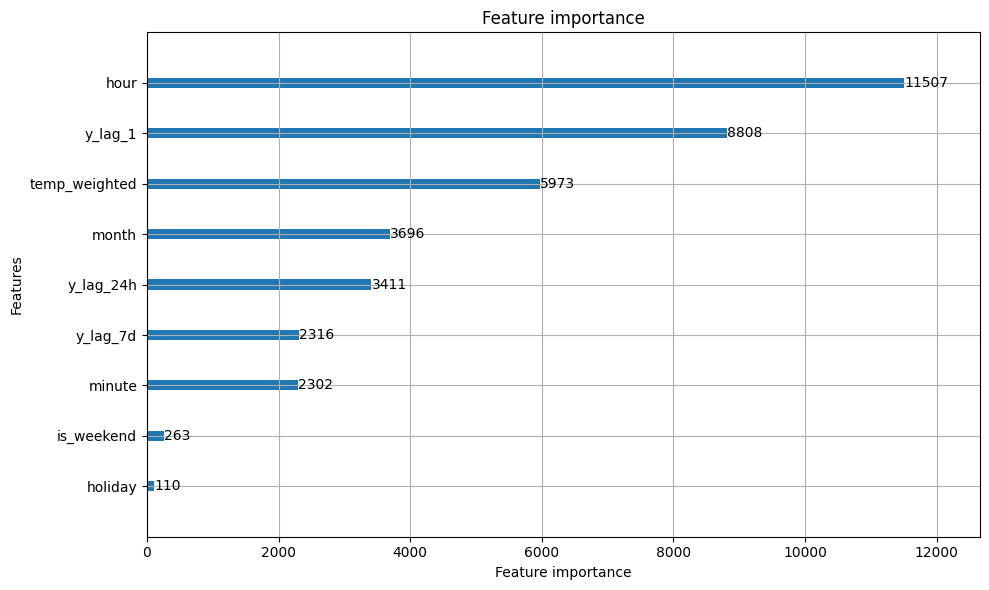

In [49]:
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt

lgb.plot_importance(final_model, max_num_features=15, figsize=(10, 6))
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

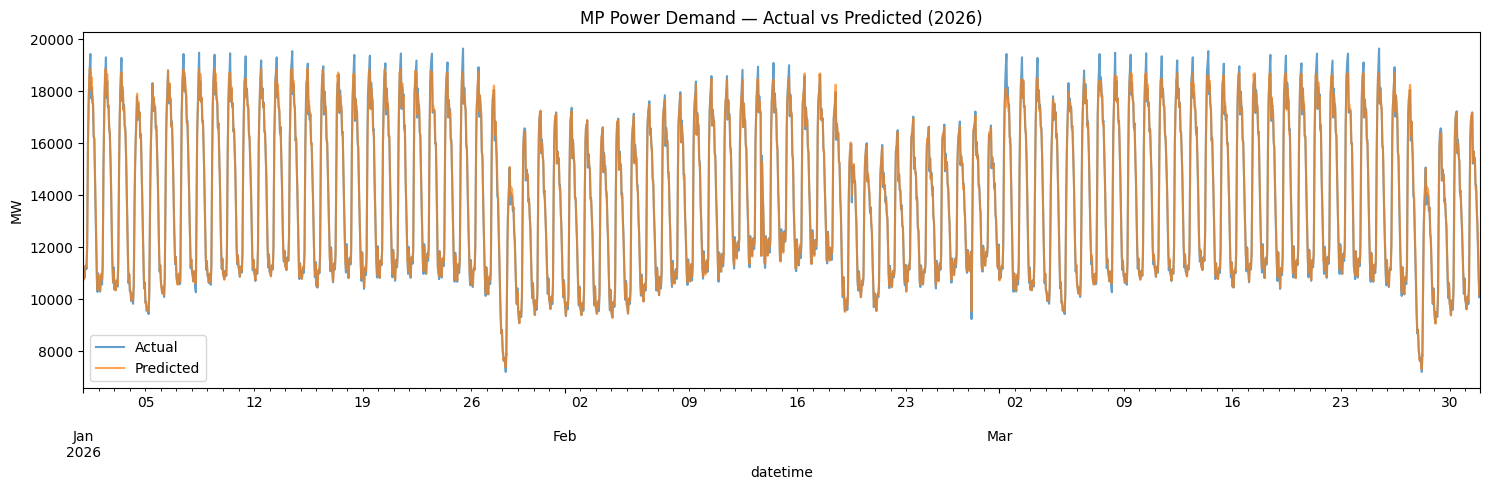

In [50]:
results = pd.DataFrame({
    'actual':    y_test.values,
    'predicted': y_pred
}, index=X_test.index)

plt.figure(figsize=(15, 5))
results['actual'].plot(label='Actual', alpha=0.7)
results['predicted'].plot(label='Predicted', alpha=0.7)
plt.title('MP Power Demand — Actual vs Predicted (2026)')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

In [51]:
final_model.save_model('mp_lgbm_final.txt')

In [52]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Train
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features=0.8,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_model.fit(X_train, y_train)

# Evaluate on val
y_val_pred = rf_model.predict(X_val)
val_mape   = np.mean(np.abs((y_val - y_val_pred) / y_val)) * 100
print(f'Val MAPE: {val_mape:.2f}%')

# Evaluate on test
y_pred_rf = rf_model.predict(X_test)
mae    = np.mean(np.abs(y_test - y_pred_rf))
rmse   = np.sqrt(np.mean((y_test - y_pred_rf) ** 2))
mape   = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
r2     = r2_score(y_test, y_pred_rf)
max_err = np.max(np.abs(y_test - y_pred_rf))

print(f'MAE      : {mae:.2f} MW')
print(f'RMSE     : {rmse:.2f} MW')
print(f'MAPE     : {mape:.2f}%')
print(f'R2       : {r2:.4f}')
print(f'Max Error: {max_err:.2f} MW')

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    2.3s


Val MAPE: 0.72%
MAE      : 145.13 MW
RMSE     : 205.22 MW
MAPE     : 1.04%
R2       : 0.9951
Max Error: 1445.82 MW


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    2.5s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.0s finished


In [53]:
import optuna
from sklearn.ensemble import RandomForestRegressor
import numpy as np

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 10, 40),
        'min_samples_split':trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':     trial.suggest_float('max_features', 0.5, 1.0),
        'n_jobs':           -1,
        'random_state':     42
    }

    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)
    mape = np.mean(np.abs((y_val - y_val_pred) / y_val)) * 100
    return mape

study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective, n_trials=30)  # 30 not 50 — RF is slower per trial

print('Best params:', study_rf.best_params)
print('Best val MAPE:', study_rf.best_value)

# Retrain with best params
best_rf = RandomForestRegressor(**study_rf.best_params, n_jobs=-1, random_state=42)
best_rf.fit(X_trainval, y_trainval)  # train on train+val combined

y_pred_rf = best_rf.predict(X_test)
mape  = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
rmse  = np.sqrt(np.mean((y_test - y_pred_rf) ** 2))
mae   = np.mean(np.abs(y_test - y_pred_rf))
r2    = r2_score(y_test, y_pred_rf)

print(f'Final Test MAPE: {mape:.2f}%')
print(f'Final Test RMSE: {rmse:.2f} MW')
print(f'Final Test MAE:  {mae:.2f} MW')
print(f'Final Test R2:   {r2:.4f}')

[I 2026-06-08 12:13:00,689] A new study created in memory with name: no-name-9617d876-a92a-40b7-8124-28d85405c07f
[I 2026-06-08 12:13:04,833] Trial 0 finished with value: 0.7229539843814109 and parameters: {'n_estimators': 314, 'max_depth': 28, 'min_samples_split': 14, 'min_samples_leaf': 2, 'max_features': 0.8253517510080605}. Best is trial 0 with value: 0.7229539843814109.
[I 2026-06-08 12:13:08,457] Trial 1 finished with value: 0.7244738258477393 and parameters: {'n_estimators': 295, 'max_depth': 30, 'min_samples_split': 16, 'min_samples_leaf': 4, 'max_features': 0.7794174383332511}. Best is trial 0 with value: 0.7229539843814109.
[I 2026-06-08 12:13:10,483] Trial 2 finished with value: 0.7329642488665311 and parameters: {'n_estimators': 171, 'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 9, 'max_features': 0.8352338848716212}. Best is trial 0 with value: 0.7229539843814109.
[I 2026-06-08 12:13:14,239] Trial 3 finished with value: 0.7898750678224726 and parameters: {'n

Best params: {'n_estimators': 258, 'max_depth': 38, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 0.9294392572105932}
Best val MAPE: 0.7089540681136403
Final Test MAPE: 0.95%
Final Test RMSE: 181.35 MW
Final Test MAE:  130.00 MW
Final Test R2:   0.9962


In [56]:
# Simple average ensemble
y_pred_ensemble = (y_pred * 0.5) + (y_pred_rf * 0.5)

mae   = np.mean(np.abs(y_test - y_pred_ensemble))
rmse  = np.sqrt(np.mean((y_test - y_pred_ensemble) ** 2))
mape  = np.mean(np.abs((y_test - y_pred_ensemble) / y_test)) * 100
r2    = r2_score(y_test, y_pred_ensemble)

print(f'Ensemble MAPE: {mape:.3f}%')
print(f'Ensemble RMSE: {rmse:.2f} MW')
print(f'Ensemble MAE:  {mae:.2f} MW')
print(f'Ensemble R2:   {r2:.4f}')

Ensemble MAPE: 0.892%
Ensemble RMSE: 171.45 MW
Ensemble MAE:  123.48 MW
Ensemble R2:   0.9966


In [57]:
# Try different weights
for lgbm_w in [0.4, 0.5, 0.6, 0.7]:
    rf_w = 1 - lgbm_w
    y_blend = (y_pred * lgbm_w) + (y_pred_rf * rf_w)
    mape = np.mean(np.abs((y_test - y_blend) / y_test)) * 100
    rmse = np.sqrt(np.mean((y_test - y_blend) ** 2))
    print(f'LGBM {lgbm_w:.0%} / RF {rf_w:.0%} → MAPE: {mape:.3f}%, RMSE: {rmse:.2f}')

LGBM 40% / RF 60% → MAPE: 0.896%, RMSE: 171.61
LGBM 50% / RF 50% → MAPE: 0.892%, RMSE: 171.45
LGBM 60% / RF 40% → MAPE: 0.890%, RMSE: 172.23
LGBM 70% / RF 30% → MAPE: 0.891%, RMSE: 173.93


In [58]:
y_pred_final = (y_pred * 0.6) + (y_pred_rf * 0.4)

mae   = np.mean(np.abs(y_test - y_pred_final))
rmse  = np.sqrt(np.mean((y_test - y_pred_final) ** 2))
mape  = np.mean(np.abs((y_test - y_pred_final) / y_test)) * 100
r2    = r2_score(y_test, y_pred_final)
max_err = np.max(np.abs(y_test - y_pred_final))
median_ae = np.median(np.abs(y_test - y_pred_final))

print(f'Final Ensemble MAPE     : {mape:.3f}%')
print(f'Final Ensemble RMSE     : {rmse:.2f} MW')
print(f'Final Ensemble MAE      : {mae:.2f} MW')
print(f'Final Ensemble R2       : {r2:.4f}')
print(f'Final Ensemble Max Error: {max_err:.2f} MW')
print(f'Final Ensemble Median AE: {median_ae:.2f} MW')

Final Ensemble MAPE     : 0.890%
Final Ensemble RMSE     : 172.23 MW
Final Ensemble MAE      : 123.75 MW
Final Ensemble R2       : 0.9965
Final Ensemble Max Error: 1449.36 MW
Final Ensemble Median AE: 93.40 MW
